In [1]:
import sys
sys.path.append('../')
import os
import os.path as osp

import utils

import torch
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(DEVICE)

/home/mdrnevich/test/QuasiDRE/SMEFT/../utils/__init__.py:4: UserWarning: The recommended fonts to use plothist were not found. You can install them by typing 'install_latin_modern_fonts' in your terminal. If it still does not work, please check the documentation at https://plothist.readthedocs.io/en/latest/usage/font_installation.html
  from . import plotting


cuda:0


## Initiate the datasets

In [2]:
LOSS = "revert"

training_settings = {}

source_file = "./data/SMEFT_SM_combined_tuple"
target_file = "./data/SMEFT_EFT_combined_tuple"


train_base_dataset = utils.preprocessing.Dataset(source_file + "_train.npy", 0)
valid_base_dataset = utils.preprocessing.Dataset(source_file + "_val.npy", 0)

train_target_dataset = utils.preprocessing.Dataset(target_file + "_train.npy", 1)
valid_target_dataset = utils.preprocessing.Dataset(target_file + "_val.npy", 1)

training_settings.update({
    "source_file": source_file,
    "target_file": target_file,
})

## Load the data

In [3]:
source_weight_norm = train_base_dataset.process(normalize_weights=True)
source_valid_weight_norm = valid_base_dataset.process(normalize_weights=True)

target_weight_norm = train_target_dataset.process(normalize_weights=True)
valid_target_dataset.process(normalize_weights=True)

tensor(0.0164)

In [4]:
train_generator_data = utils.preprocessing.CombinedDataset(train_base_dataset, train_target_dataset)
valid_generator_data = utils.preprocessing.CombinedDataset(valid_base_dataset, valid_target_dataset)

## Do some data preprocessing for standardized inputs and weights

In [5]:
X_scaler, train_weight_norm = utils.preprocessing.get_scaling(train_generator_data)
_, valid_weight_norm = utils.preprocessing.get_scaling(valid_generator_data)
print(train_weight_norm, valid_weight_norm)

100%|██████████| 350/350 [00:01<00:00, 258.95it/s]

tensor(1.0000) tensor(1.0000)


## Prepare the data for training

In [6]:
random_seed = 0

torch.manual_seed(random_seed)
batch_size = int(2**8)
training_settings.update({
    "batch_size": batch_size,
    "random_seed": random_seed
})

train_loader = DataLoader(train_generator_data, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_generator_data, batch_size=batch_size, shuffle=False)

## Construct the model

In [7]:
inputs = 16
hidden_nodes = [128, 256, 128]
outputs = 1

t0 = None
t1 = None
if LOSS in ["mse", "pare"]:
    t0 = 25619
    t1 = 58
    model = utils.models.Classifier(inputs, hidden_nodes, outputs, final_activation="linear")
else:
    model = utils.models.Classifier(inputs, hidden_nodes, outputs)
print(model)
print("----------")

model = model.to(DEVICE)

learning_rate = 3e-5
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

training_settings.update({
    "learning_rate": learning_rate,
    "optimizer": "Adam"
})



Classifier(
  (model): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=1, bias=True)
    (7): Sigmoid()
  )
)
----------


In [8]:
SAVE_DIR = "./models/"
if not osp.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

modelname = "classifier_{}_batch{}".format(LOSS, batch_size)
print(modelname)

classifier_revert_batch256


## Perform the training

In [9]:
n_epochs = 1500
stale_epochs = 0
best_valid_loss = 99999
patience = 20
max_num_batches = int(int(1e5) / batch_size)
t = tqdm(range(0, n_epochs))

training_losses = [utils.train.test(
        model,
        train_loader,
        X_scaler,
        loss=LOSS,
        t0=t0,
        t1=t1,
        weight_norm=train_weight_norm,
        max_num_batches=max_num_batches,
        device=DEVICE,
        progress_bar=False,
        leave=False
    )[1],]
validation_losses = [utils.train.test(
        model,
        valid_loader,
        X_scaler,
        loss=LOSS,
        t0=t0,
        t1=t1,
        weight_norm=valid_weight_norm,
        device=DEVICE,
        progress_bar=False,
        leave=False
    )[1],]


for epoch in t:
    loss = utils.train.train(
        model,
        optimizer,
        train_loader,
        X_scaler,
        loss=LOSS,
        t0=t0,
        t1=t1,
        weight_norm=train_weight_norm,
        max_num_batches=max_num_batches,
        device=DEVICE,
        leave=bool(epoch == n_epochs - 1),
        progress_bar=False,
    )
    #loss -= optimal_train_loss
    training_losses.append(loss[1])

    valid_loss = utils.train.test(
        model,
        valid_loader,
        X_scaler,
        loss=LOSS,
        t0=t0,
        t1=t1,
        weight_norm=valid_weight_norm,
        device=DEVICE,
        leave=bool(epoch == n_epochs - 1),
        progress_bar=False,
    )
    validation_losses.append(valid_loss[1])
    print("Epoch: {:02d}, Training Loss:   {:.4f}".format(epoch, loss[1]))
    print("           Validation Loss: {:.4f}".format(valid_loss[1]))

    if valid_loss[1] < best_valid_loss:
        best_valid_loss = valid_loss[1]
        training_settings.update({
            "n_epochs": epoch+1,
            "training_losses": training_losses,
            "validation_losses": validation_losses
        })
        model_metadata = utils.train.get_model_metadata(training_settings, model, X_scaler, train_weight_norm)
        utils.train.save_model_data(model, model_metadata, savedir=SAVE_DIR, name=modelname, save_onnx=False, device=DEVICE)
        print("New best model saved to: {}.zip".format(osp.join(SAVE_DIR, modelname)))
        #torch.save(model.state_dict(), modpath)
        stale_epochs = 0
    else:
        print("Stale epoch")
        stale_epochs += 1
    if stale_epochs >= patience:
        print("Early stopping after %i stale epochs" % patience)
        break

  0%|          | 0/1500 [00:00<?, ?it/s]

Epoch: 00, Training Loss:   0.8999
           Validation Loss: 0.8838
New best model saved to: ./models/classifier_revert_batch256.zip
Epoch: 01, Training Loss:   0.8788
           Validation Loss: 0.8783
New best model saved to: ./models/classifier_revert_batch256.zip
Epoch: 02, Training Loss:   0.8750
           Validation Loss: 0.8745
New best model saved to: ./models/classifier_revert_batch256.zip
Epoch: 03, Training Loss:   0.8716
           Validation Loss: 0.8708
New best model saved to: ./models/classifier_revert_batch256.zip
Epoch: 04, Training Loss:   0.8677
           Validation Loss: 0.8675
New best model saved to: ./models/classifier_revert_batch256.zip
Epoch: 05, Training Loss:   0.8677
           Validation Loss: 0.8649
New best model saved to: ./models/classifier_revert_batch256.zip
Epoch: 06, Training Loss:   0.8611
           Validation Loss: 0.8631
New best model saved to: ./models/classifier_revert_batch256.zip
Epoch: 07, Training Loss:   0.8604
           Validatio

### Look at loss curves

Text(0, 0.5, 'REVERT Loss')

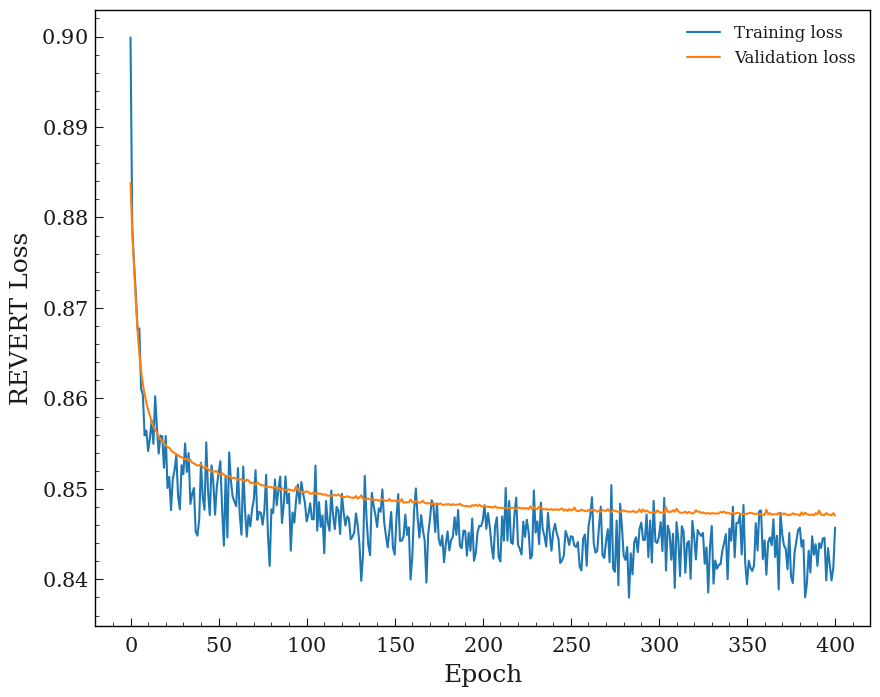

In [11]:
fig,ax = plt.subplots()
fig.set_size_inches(10, 8)

starting_epoch = 1
training_loss_per_epoch = np.array(training_losses[starting_epoch:])
validation_loss_per_epoch = np.array(validation_losses[starting_epoch:])


t1 = np.arange(len(training_loss_per_epoch))
t2 = np.arange(len(validation_loss_per_epoch))
ax.plot(t1, training_loss_per_epoch, '-', label="Training loss", c='tab:blue')
ax.plot(t2, validation_loss_per_epoch, '-', label="Validation loss", c='tab:orange')

ax.legend()
ax.set_xlabel("Epoch")
ax.set_ylabel("{} Loss".format(LOSS.upper()))